# MonReader: Computer Vision for Automated Document Digitization 

##  Background & Context
Artificial Intelligence and Computer Vision are no longer technologies of the future—they are actively revolutionizing industries today. Our client develops intelligent edge devices and CV solutions designed to seamlessly integrate into existing data flows, enabling everyday devices to recognize faces, objects, and motion. 

This project centers around **MonReader**, a mobile document digitization application built for researchers, the visually impaired, and anyone requiring fast, high-quality, automatic bulk document scanning. Instead of manually capturing each page, the user simply flips the pages in front of their smartphone camera. MonReader's pipeline automatically detects the page flips, captures high-resolution images, crops and dewarps them, enhances text contrast, and applies ML-powered OCR and redaction.

##  The Core Problem
To make the MonReader experience seamless, the application must perfectly time its high-resolution captures. It needs to know exactly *when* a page is being flipped versus when it is stationary. 

Our current challenge is to build a robust classification model capable of analyzing camera preview data to accurately predict the action of page flipping.

##  Data Overview
The dataset consists of short video clips captured from smartphones during the document scanning process. 
* **Extraction:** The videos have been clipped and decomposed into sequential image frames.
* **Format:** Images are saved to disk with the naming convention `VideoID_FrameNumber`.
* **Labels:** Each frame/sequence is mapped to a binary label: **Flipping** (1) or **Not Flipping** (0).

##  Project Goal & Success Metrics
**The Objective:** 
Develop a Machine Learning/Computer Vision model that can accurately predict whether a page is being flipped using a single image (or sequence of images).

**Success Metric:** 
Model performance will be evaluated strictly on the **F1 Score** (the higher, the better). Maximizing the F1 score ensures a healthy balance between Precision (minimizing false captures when a page isn't flipping) and Recall (ensuring we don't miss a legitimate page flip).

#### 1- Import Required Libraries
First, we need to import PyTorch, the torchvision modules for image processing, and a few standard Python libraries for handling file paths.

In [61]:
# import torch
import os
import torch
import torch.nn as nn
# import torchevision 

import torchvision
from torchvision import  transforms
from torchvision.transforms import ToTensor
###################
##################
###################


# from torch.utils.data import DataLoader, random_split

import torchvision.models as tm

# 
import matplotlib.pyplot as plt
import numpy as np


# Set random seed for reproducibility
torch.manual_seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


#### 2- Define Data Transformations and Augmentation
Because smartphone camera feeds can vary in lighting, angle, and framing, applying data augmentation to the training set will help the model generalize better and prevent it from simply memorizing the training images.

In [62]:
# Set folder paths containing images folder and the training and test data
import os
base_dir = r"C:\Users\Dell\Desktop\APZIVA\MonReader Project\images\images"
train_dir = os.path.join(base_dir , 'training') # Training data path
test_dir = os.path.join(base_dir ,'testing') # Test data path

#### 3-Visualize a few training examples of the images from each class to better sense of the problem

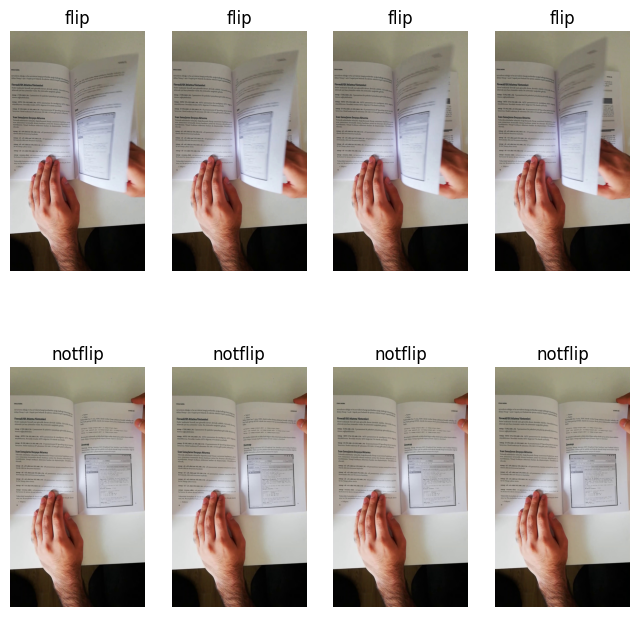

In [63]:
%matplotlib inline

import matplotlib.image as mpimg
from pathlib import Path

# Data path to classes
flip_dir = os.path.join(train_dir ,"flip")
notflip_dir = os.path.join(train_dir, "notflip")

# Parameters for our graph; we'll output images in a 2x4 configuration
nrows = 2
ncols = 4

pic_index = 0 # Index for iterating over images
# Set up matplotlib fig, and size it to fit 2x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols*2, nrows*4)

pic_index+=8

flip_pix = [os.path.join(flip_dir, fname)
                for fname in os.listdir(flip_dir)[ pic_index-4:pic_index]
               ]

not_flip_pix = [os.path.join(notflip_dir, fname)
                for fname in os.listdir(notflip_dir)[ pic_index-4:pic_index]
               ]

for i, img_path in enumerate(flip_pix + not_flip_pix ):
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.title.set_text(os.path.basename(os.path.dirname(img_path)))
  sp.axis('Off') # Don't show axes (or gridlines)

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()

- Based on the images provided, here are the key visual differences between the two classes :

    - Flip Images

    **Hand Position**: The right hand is actively grasping or pinching the edge of the page to initiate the turn.

    **Page Deformation**: The right page is visibly lifted and pulled toward the left, creating a distinct curve in the paper.
    
    - Notflip Images

    **Flat Pages**:The book is completely open, and both the left and right pages are resting flat

    **Hand Position**: Both hands are resting flat on the edges of the book to hold it open, with no fingers actively lifting the paper.
    
    **Clear Visibility**: There are no moving pages obstructing the view, meaning the text and graphics (like the table on the right page) are fully flat and visible.


####  Define transforms

https://www.geeksforgeeks.org/python/image-datasets-dataloaders-and-transforms-in-pytorch/

https://docs.pytorch.org/vision/0.13/transforms.html

input data can be in different sizes/shapes so transformation and augmentation on rotation/brightness helps generalization 

In [64]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

#### Build datasets and split off a validation set

In [65]:
from torch.utils.data import DataLoader, random_split

full_train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=test_transform)

class_names = full_train_dataset.classes
print(f"Classes: {class_names}")  # should print ['flip', 'notflip']

val_size = int(0.15 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

Classes: ['flip', 'notflip']


####  Build the model  with ResNet

ResNet-18 is an 18-layer Convolutional Neural Network (CNN) Consists of 17 convolutional layers and 1 fully connected layer.

In [66]:
model = tm.resnet18(weights=tm.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)  # this layer stays trainable
model = model.to(device)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)  # only optimize fc

#### Run predictions on the test set

In [67]:
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

#### Accuracy and F1 Score

In [68]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds, pos_label=0)  # pos_label=0 -> 'flip' class, check your class_names order

print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Test F1 Score: {f1:.4f}')

Test Accuracy: 48.58%
Test F1 Score: 0.6539


#### Confusion matrix — numbers

In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_preds)
print(cm)

[[290   0]
 [307   0]]


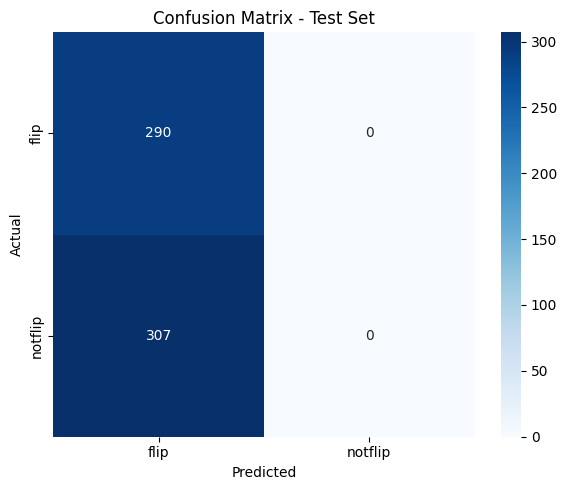

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = full_train_dataset.classes  # ['flip', 'notflip']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

In [71]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, test_preds, target_names=class_names))

              precision    recall  f1-score   support

        flip       0.49      1.00      0.65       290
     notflip       0.00      0.00      0.00       307

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597



c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

The dataset seemed balance between the flipped and non flipped images, so no pre-processing or cleaning was that necessary.

- With only ~600 test images, keep an eye on the confusion matrix's off diagonal cells specifically, since our success metric is F1, what matters most is how many flip images get misclassified as notflip (missed page turns) versus the reverse (false triggers). Those two error types have different realworld costs for MonReader (missing a page turn = lost page; false trigger = wasted extra photo), so it's worth reporting both directions even though F1 combines them into one number.

### 1: The model sees a flip happening, but calls it "not flipping."


This means MonReader misses the moment someone turns the page. Since the whole point of the app is to snap a picture right when a page is stable after a flip, missing this means you lose that page entirely, it just never gets scanned. That's a real problem, not a minor annoyance.

### 2: The model sees a stationary page, but calls it "flipping."

This means the app thinks a flip is happening when it isn't. The cost here is much smaller — worst case, it snaps an extra photo it didn't need to, or delays taking the photo by a beat. Annoying, but nobody loses data.